In [1]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import glob

from src.parsers import HMParser, CotevParser

from src.utils import load_multiple_upacs_pv, iterate_resources

2025-03-03 20:46:07,280	WARNING deprecation.py:50 -- DeprecationWarning: `DirectStepOptimizer` has been deprecated. This will raise an error in the future!
2025-03-03 20:46:07,546	WARNING deprecation.py:50 -- DeprecationWarning: `build_tf_policy` has been deprecated. This will raise an error in the future!
2025-03-03 20:46:07,548	WARNING deprecation.py:50 -- DeprecationWarning: `build_policy_class` has been deprecated. This will raise an error in the future!


In [2]:
# Data parsing

# EC data for non-renewable generators and batteries
data_ec = HMParser(file_path='/Users/ecgomes/DataspellProjects/pyecom/data/EC_V4.xlsx', ec_id=1)
data_ec.parse()

# EV data from the EV4EU simulator
data_ev = CotevParser(population_path=
                      '/Users/ecgomes/DataspellProjects/pyecom/data/simulation_dataframes_2years/population_731.csv',
                      driving_history_path=
                      '/Users/ecgomes/DataspellProjects/pyecom/data/simulation_dataframes_2years/ev_driving_history_731.csv',
                      assigned_segments_path='/Users/ecgomes/DataspellProjects/pyecom/data/simulation_dataframes_2years/assigned_segments_731.csv',
                      parse_date_start='2019',
                      parse_date_end='2020')
data_ev.parse()

# UPAC Data load
data_upacs = load_multiple_upacs_pv('/Users/ecgomes/Documents/PhD/UPAC data/upac*_pv.csv', resample='H')

In [3]:
# Create resources for the training environment

dataset_resources = iterate_resources(u=data_upacs, c=data_ec, e=data_ev, mode='monthly')

In [4]:
# Load the data

test_data = {}

for results in ['priority_baseline_paper_v0', 'priority_baseline_paper_v1', 'priority_baseline_paper_v2',
                'priority_paper_v0', 'priority_paper_v1', 'priority_paper_v2', 'priority_paper_v3',
                'priority_seq_paper_v0', 'priority_seq_paper_v1']:
    temp_data = pd.DataFrame({})
    for file in glob.glob('../{}/*.csv'.format(results)):
        data = pd.read_csv(file, index_col=0)
        name = file.split('/')[-1].split('.')[0]
    
        # Create index for data
        data.index = pd.date_range(start=name, periods=data.shape[0], freq='H')
    
        # Add data to the DataFrame
        temp_data = pd.concat([temp_data, data], axis=0)
    
    # Sort the data
    temp_data = temp_data.sort_index()
    
    # Add the data to the dictionary
    test_data[results] = temp_data

In [5]:
# Print the subkeys of the dictionary

for key in test_data.keys():
    print(key)
    print(test_data[key].keys())
    print()

priority_baseline_paper_v0
Index(['ren_generator_08', 'ren_generator_06', 'ren_generator_02',
       'ren_generator_09', 'ren_generator_13', 'storage_01',
       'storage_01_charge', 'storage_01_discharge', 'storage_02',
       'storage_02_charge', 'storage_02_discharge', 'storage_03',
       'storage_03_charge', 'storage_03_discharge', 'ev_01', 'ev_01_charge',
       'ev_01_discharge', 'ev_02', 'ev_02_charge', 'ev_02_discharge', 'ev_03',
       'ev_03_charge', 'ev_03_discharge', 'ev_04', 'ev_04_charge',
       'ev_04_discharge', 'ev_05', 'ev_05_charge', 'ev_05_discharge',
       'imports', 'exports'],
      dtype='object')

priority_baseline_paper_v1
Index(['ren_generator_08', 'ren_generator_06', 'ren_generator_02',
       'ren_generator_09', 'ren_generator_13', 'storage_01',
       'storage_01_charge', 'storage_01_discharge', 'storage_02',
       'storage_02_charge', 'storage_02_discharge', 'storage_03',
       'storage_03_charge', 'storage_03_discharge', 'ev_01', 'ev_01_charge',
   

In [6]:
# Check day '2020-01-01'
# We want to build a consumption and a production dataframe
# Consumption will have the load, the storage charge, the EV charge and the exports
# Production will have the renewable generators, the non-renewable generators, the storage discharge and the EV discharge
# Load will come from the UPAC data

# Create the consumption dataframes
consumptions = {}
for key in ['priority_paper_v3']: #test_data.keys():
    consumption = pd.DataFrame(index=test_data[key].index, columns=['load', 'storage_charge',
                                                                     'ev_charge', 'exports'])
    consumption['load'] = sum(data_upacs[upac].load.values for upac in data_upacs.keys())
    consumption['storage_charge'] = test_data[key][['storage_01_charge',
                                                    'storage_02_charge',
                                                    'storage_03_charge']].sum(axis=1)
    consumption['ev_charge'] = test_data[key][['ev_01_charge',
                                               'ev_02_charge',
                                               'ev_03_charge',
                                               'ev_04_charge',
                                               'ev_05_charge']].sum(axis=1)
    
    consumption['exports'] = test_data[key]['exports']
    
    consumptions[key] = consumption

# Create the production dataframe
productions = {}
for key in ['priority_paper_v3']: #test_data.keys():
    production = pd.DataFrame(index=test_data[key].index, columns=['ren_gen',
                                                                    'storage_discharge',
                                                                    'ev_discharge'])
    production['ren_gen'] = test_data[key][['ren_generator_02',
                                            'ren_generator_06',
                                            'ren_generator_08',
                                            'ren_generator_09',
                                            'ren_generator_13']].sum(axis=1)
    production['storage_discharge'] = test_data[key][['storage_01_discharge_eff',
                                                      'storage_02_discharge_eff',
                                                      'storage_03_discharge_eff']].sum(axis=1)
    production['ev_discharge'] = test_data[key][['ev_01_discharge_eff',
                                                 'ev_02_discharge_eff',
                                                 'ev_03_discharge_eff',
                                                 'ev_04_discharge_eff',
                                                 'ev_05_discharge_eff']].sum(axis=1)
    
    production['imports'] = test_data[key]['imports']
    
    productions[key] = production

In [7]:
# Aux for calculating costs

def calculate_costs(model_results, model_data):

    datapoint_dict = {}
    overall_dict = pd.DataFrame({}, index=['Costs', 'Profits'])

    for key in model_data.keys():

        current_data = model_results.loc[key].copy(deep=True)
        current_data = current_data[['ren_generator_08',
                                     'ren_generator_06',
                                     'ren_generator_02',
                                     'ren_generator_09',
                                     'ren_generator_13',
                                     'storage_01_discharge',
                                     'storage_02_discharge',
                                     'storage_03_discharge',
                                     'ev_01_discharge',
                                     'ev_02_discharge',
                                     'ev_03_discharge',
                                     'ev_04_discharge',
                                     'ev_05_discharge',
                                     'imports',
                                     'exports']]

        for current_key in current_data.keys()[:-2]:
            current_data[current_key] = current_data[current_key] * 0.0

        '''
        current_data['ren_generator_08'] *= model_data[key][0].cost
        current_data['ren_generator_06'] *= model_data[key][1].cost
        current_data['ren_generator_02'] *= model_data[key][2].cost
        current_data['ren_generator_09'] *= model_data[key][3].cost
        current_data['ren_generator_13'] *= model_data[key][4].cost

        current_data['storage_01_discharge'] *= model_data[key][10].cost_discharge
        current_data['storage_02_discharge'] *= model_data[key][11].cost_discharge
        current_data['storage_03_discharge'] *= model_data[key][12].cost_discharge

        current_data['ev_01_discharge'] *= model_data[key][13].cost_discharge
        current_data['ev_02_discharge'] *= model_data[key][14].cost_discharge
        current_data['ev_03_discharge'] *= model_data[key][15].cost_discharge
        current_data['ev_04_discharge'] *= model_data[key][16].cost_discharge
        current_data['ev_05_discharge'] *= model_data[key][17].cost_discharge
        '''

        current_data['imports'] *= model_data[key][-1].import_cost
        current_data['exports'] *= model_data[key][-1].export_cost

        current_data = current_data.round(4)

        datapoint_dict[key] = current_data

        overall_dict[key] = [current_data.sum().iloc[:-1].sum(), current_data.sum().iloc[-1]]

    overall_dict = overall_dict.T

    return overall_dict, datapoint_dict

In [8]:
costs = {}
monthly_costs = {}
final_costs = {}

for key in test_data.keys():
    
    cost, monthly_cost = calculate_costs(test_data[key], dataset_resources)
    
    # Sort the index and assign it as a datetime index
    cost = cost.sort_index()
    cost.index = pd.to_datetime(cost.index)
    
    df_final_cost = pd.DataFrame()
    # Sort the index and assign it as a datetime index
    for subkey in monthly_cost.keys():
        monthly_cost[subkey] = monthly_cost[subkey].sort_index()
        monthly_cost[subkey].index = pd.date_range(start='{}-01-01'.format(subkey),
                                                   periods=len(monthly_cost[subkey]), freq='H')
        # Only the date, exclude the hours
        #seq_monthly_costs[key].index = pd.to_datetime(seq_monthly_costs[key].index.date)
    
        # Append the data to the dataframe
        df_final_cost = pd.concat([df_final_cost, monthly_cost[subkey]])
    df_final_cost = df_final_cost.sort_index()
    
    # Add the data to the dictionary
    costs[key] = cost
    monthly_costs[key] = monthly_cost
    final_costs[key] = df_final_cost

In [9]:
final_costs

{'priority_baseline_paper_v0':                      ren_generator_08  ren_generator_06  ren_generator_02  \
 2019-01-01 01:00:00               0.0               0.0               0.0   
 2019-01-01 02:00:00               0.0               0.0               0.0   
 2019-01-01 03:00:00               0.0               0.0               0.0   
 2019-01-01 04:00:00               0.0               0.0               0.0   
 2019-01-01 05:00:00               0.0               0.0               0.0   
 ...                               ...               ...               ...   
 2020-12-31 20:00:00               0.0               0.0               0.0   
 2020-12-31 21:00:00               0.0               0.0               0.0   
 2020-12-31 22:00:00               0.0               0.0               0.0   
 2020-12-31 23:00:00               0.0               0.0               0.0   
 2021-01-01 00:00:00               0.0               0.0               0.0   
 
                      ren_genera

In [10]:
# Group by month

df_costs_grouped = pd.DataFrame({})
df_costs_grouped['adaptive_nogen'] = final_costs['priority_paper_v1']\
    [list(final_costs['priority_paper_v1'].columns)[:-1]].sum(axis=1)
df_costs_grouped['seq_nogen'] = final_costs['priority_seq_paper_v1']\
    [list(final_costs['priority_seq_paper_v1'].columns)[:-1]].sum(axis=1).values
df_costs_grouped['marl_nogen'] = final_costs['priority_baseline_paper_v1']\
    [list(final_costs['priority_baseline_paper_v1'].columns)[:-1]].sum(axis=1).values
df_costs_grouped['adaptive_gen'] = final_costs['priority_paper_v0']\
    [list(final_costs['priority_paper_v0'].columns)[:-1]].sum(axis=1)
df_costs_grouped['seq_gen'] = final_costs['priority_seq_paper_v0']\
    [list(final_costs['priority_seq_paper_v0'].columns)[:-1]].sum(axis=1).values
df_costs_grouped['marl_gen'] = final_costs['priority_baseline_paper_v0']\
    [list(final_costs['priority_baseline_paper_v0'].columns)[:-1]].sum(axis=1).values
df_costs_grouped['baseline_v2'] = final_costs['priority_baseline_paper_v2']\
    [list(final_costs['priority_baseline_paper_v2'].columns)[:-1]].sum(axis=1).values
df_costs_grouped['adaptive_v2'] = final_costs['priority_paper_v2']\
    [list(final_costs['priority_paper_v2'].columns)[:-1]].sum(axis=1).values
df_costs_grouped['adaptive_v3'] = final_costs['priority_paper_v3']\
    [list(final_costs['priority_paper_v3'].columns)[:-1]].sum(axis=1).values

df_costs_grouped = df_costs_grouped.groupby([df_costs_grouped.index.year,
                                             df_costs_grouped.index.month]).sum()

df_export_grouped = pd.DataFrame({})
df_export_grouped['adaptive_nogen'] = final_costs['priority_paper_v1']['exports']
df_export_grouped['seq_nogen'] = final_costs['priority_seq_paper_v1']['exports'].values
df_export_grouped['marl_nogen'] = final_costs['priority_baseline_paper_v1']['exports'].values
df_export_grouped['adaptive_gen'] = final_costs['priority_paper_v0']['exports']
df_export_grouped['seq_gen'] = final_costs['priority_seq_paper_v0']['exports'].values
df_export_grouped['marl_gen'] = final_costs['priority_baseline_paper_v0']['exports'].values
df_export_grouped['baseline_v2'] = final_costs['priority_baseline_paper_v2']['exports'].values
df_export_grouped['adaptive_v2'] = final_costs['priority_paper_v2']['exports'].values
df_export_grouped = df_export_grouped.groupby([df_export_grouped.index.year,
                                               df_export_grouped.index.month]).sum()

In [11]:
df_costs_grouped.sum()

adaptive_nogen     6070.224619
seq_nogen          6227.764029
marl_nogen         6199.894419
adaptive_gen       5927.985129
seq_gen             6140.41743
marl_gen           6198.097346
baseline_v2       10076.972668
adaptive_v2        5108.098232
adaptive_v3        6944.833444
dtype: object

In [12]:
#test_data['priority_paper_v3'][['energy_history', 'imports', 'exports']].loc['2019-01-02'].sum(axis=1)
productions['priority_paper_v3'].loc['2019-01-02'].sum(axis=1) - consumptions['priority_paper_v3'].loc['2019-01-02'].sum(axis=1)

2019-01-02 00:00:00    1.776357e-15
2019-01-02 01:00:00    1.776357e-15
2019-01-02 02:00:00    1.776357e-15
2019-01-02 03:00:00    1.776357e-15
2019-01-02 04:00:00    1.776357e-15
2019-01-02 05:00:00    0.000000e+00
2019-01-02 06:00:00   -1.776357e-15
2019-01-02 07:00:00    0.000000e+00
2019-01-02 08:00:00    0.000000e+00
2019-01-02 09:00:00    0.000000e+00
2019-01-02 10:00:00    0.000000e+00
2019-01-02 11:00:00    0.000000e+00
2019-01-02 12:00:00   -1.776357e-15
2019-01-02 13:00:00    0.000000e+00
2019-01-02 14:00:00    0.000000e+00
2019-01-02 15:00:00    0.000000e+00
2019-01-02 16:00:00    0.000000e+00
2019-01-02 17:00:00    0.000000e+00
2019-01-02 18:00:00    0.000000e+00
2019-01-02 19:00:00    1.776357e-15
2019-01-02 20:00:00    0.000000e+00
2019-01-02 21:00:00    0.000000e+00
2019-01-02 22:00:00   -8.881784e-16
2019-01-02 23:00:00    0.000000e+00
dtype: float64

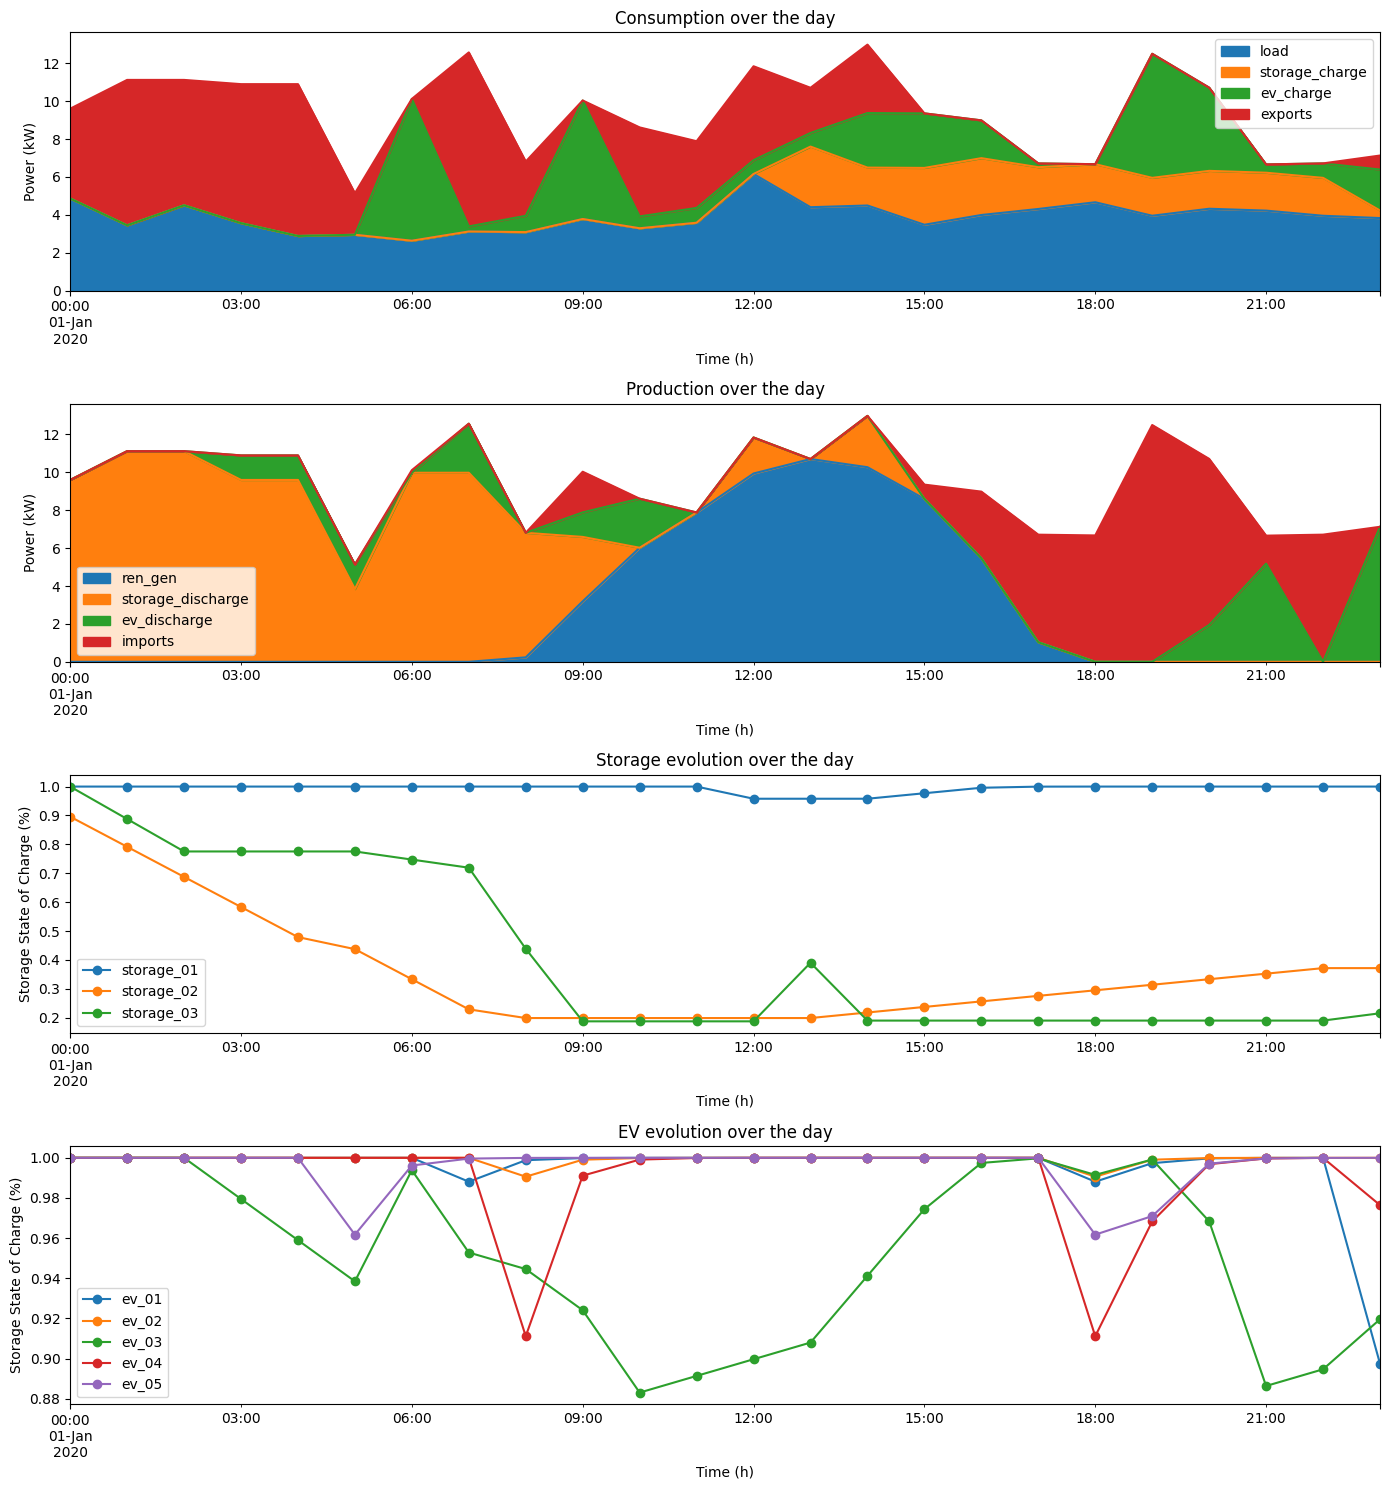

In [24]:
# Plot the resource usage over a day

DAY = '2020-01-01'
MODEL = 'priority_paper_v3'
# 'priority_baseline_paper_v0', 'priority_baseline_paper_v1', 'priority_paper_v0'
# 'priority_paper_v1', 'priority_seq_paper_v0', 'priority_seq_paper_v1'

fig, ax = plt.subplots(4, 1, figsize=(14, 15))

# Do an area plot for the consumption
consumptions[MODEL].loc[DAY].plot(kind='area', ax=ax[0], stacked=True)

# Do an area plot for the production
productions[MODEL].loc[DAY].plot(kind='area', ax=ax[1], stacked=True)

ax[0].set_title('Consumption over the day')
ax[0].set_ylabel('Power (kW)')
ax[0].set_xlabel('Time (h)')

ax[1].set_title('Production over the day')
ax[1].set_ylabel('Power (kW)')
ax[1].set_xlabel('Time (h)')

# Plot the evolution of the storages over the day
test_data[MODEL].loc[DAY][['storage_01', 'storage_02', 'storage_03']].plot(ax=ax[2], marker='o')
ax[2].set_title('Storage evolution over the day')
ax[2].set_ylabel('Storage State of Charge (%)')
ax[2].set_xlabel('Time (h)')

# Plot the evolution of the EVs over the day
test_data[MODEL].loc[DAY][['ev_01', 'ev_02', 'ev_03', 'ev_04', 'ev_05']].plot(ax=ax[3], marker='o', linestyle='-')
ax[3].set_title('EV evolution over the day')
ax[3].set_ylabel('Storage State of Charge (%)')
ax[3].set_xlabel('Time (h)')

plt.tight_layout()

plt.show()

In [55]:
test_data['priority_paper_v3'].loc['2019-01-02']['aggregator_action']

2019-01-02 00:00:00    0.0
2019-01-02 01:00:00    0.0
2019-01-02 02:00:00    0.0
2019-01-02 03:00:00    0.0
2019-01-02 04:00:00    0.0
2019-01-02 05:00:00    0.0
2019-01-02 06:00:00    0.0
2019-01-02 07:00:00    0.0
2019-01-02 08:00:00    0.0
2019-01-02 09:00:00    0.0
2019-01-02 10:00:00    0.0
2019-01-02 11:00:00    0.0
2019-01-02 12:00:00    0.0
2019-01-02 13:00:00    0.0
2019-01-02 14:00:00    0.0
2019-01-02 15:00:00    0.0
2019-01-02 16:00:00    0.0
2019-01-02 17:00:00    0.0
2019-01-02 18:00:00    0.0
2019-01-02 19:00:00    0.0
2019-01-02 20:00:00    0.0
2019-01-02 21:00:00    0.0
2019-01-02 22:00:00    0.0
2019-01-02 23:00:00    0.0
Name: aggregator_action, dtype: float64

In [25]:
# Calculate the SS and SC for each model

MODEL = 'priority_paper_v3'

df_ss_sc = pd.DataFrame({})

# Set the baseline values
df_ss_sc['baseline_prod'] = productions[MODEL]['ren_gen']
df_ss_sc['baseline_cons'] = consumptions[MODEL]['load']
df_ss_sc['baseline_imports'] = df_ss_sc['baseline_cons'] - df_ss_sc['baseline_prod']
df_ss_sc['baseline_exports'] = df_ss_sc['baseline_prod'] - df_ss_sc['baseline_cons']

# Set to zero the negative values
df_ss_sc['baseline_imports'] = df_ss_sc['baseline_imports'].clip(lower=0)
df_ss_sc['baseline_exports'] = df_ss_sc['baseline_exports'].clip(lower=0)

# Set the RL values
df_ss_sc['rl_prod'] = productions[MODEL][productions[MODEL].columns[:-1]].sum(axis=1)
df_ss_sc['rl_cons'] = consumptions[MODEL][consumptions[MODEL].columns[:-1]].sum(axis=1)
df_ss_sc['rl_imports'] = productions[MODEL]['imports']
df_ss_sc['rl_exports'] = consumptions[MODEL]['exports']

# Set to zero the negative values
df_ss_sc['rl_imports'] = df_ss_sc['rl_imports'].clip(lower=0)
df_ss_sc['rl_exports'] = df_ss_sc['rl_exports'].clip(lower=0)

# Calculate the metrics
df_ss_sc['baseline_ss'] = (df_ss_sc['baseline_cons'] - df_ss_sc['baseline_imports']) / df_ss_sc['baseline_cons']
df_ss_sc['baseline_sc'] = (df_ss_sc['baseline_prod'] - df_ss_sc['baseline_exports']) / df_ss_sc['baseline_prod']

df_ss_sc['rl_ss'] = (df_ss_sc['rl_cons'] - df_ss_sc['rl_imports']) / df_ss_sc['rl_cons']
df_ss_sc['rl_sc'] = (df_ss_sc['rl_prod'] - df_ss_sc['rl_exports']) / df_ss_sc['rl_prod']

In [26]:
df_ss_sc.loc['2019-01-02'].mean()

baseline_prod       2.578281
baseline_cons       5.352456
baseline_imports    3.496388
baseline_exports    0.722214
rl_prod             5.986085
rl_cons             7.176656
rl_imports          3.260886
rl_exports          2.070316
baseline_ss         0.325071
baseline_sc         0.918344
rl_ss               0.639737
rl_sc               0.795288
dtype: float64

In [83]:
test_data['priority_paper_v3'].loc['2019-01-02']

,ren_generator_08,ren_generator_06,ren_generator_02,ren_generator_09,ren_generator_13,storage_01,storage_01_charge,storage_01_charge_eff,storage_01_discharge,storage_01_discharge_eff,...,ev_04_discharge_eff,ev_05,ev_05_charge,ev_05_charge_eff,ev_05_discharge,ev_05_discharge_eff,imports,exports,energy_history,order_history
2019-01-02 00:00:00,0.000000,0.002767,0.000000,0.000230,0.000000,0.199662,0.0,0.00,0.000000,0.000000,...,0.0,0.200000,0.00,0.000,0.00,0.000,4.555675,0.000000,-4.555675,"['ev_05', 'storage_01', 'ev_01', 'storage_03',..."
2019-01-02 01:00:00,0.000000,0.002793,0.000000,0.000240,0.000000,0.199662,0.0,0.00,0.000000,0.000000,...,0.0,0.200000,0.00,0.000,0.00,0.000,3.923973,0.000000,-3.923973,"['ev_05', 'storage_01', 'storage_03', 'ev_01',..."
2019-01-02 02:00:00,0.000000,0.002823,0.000000,0.000383,0.000000,0.199662,0.0,0.00,0.000000,0.000000,...,0.0,0.200000,0.00,0.000,0.00,0.000,3.515590,0.000000,-3.515590,"['ev_05', 'storage_03', 'storage_01', 'ev_01',..."
2019-01-02 03:00:00,0.000000,0.002943,0.000000,0.000830,0.000000,0.199662,0.0,0.00,0.000000,0.000000,...,0.0,0.200000,0.00,0.000,0.00,0.000,2.979777,0.000000,-2.979777,"['ev_05', 'storage_03', 'storage_01', 'ev_01',..."
2019-01-02 04:00:00,0.000000,0.002793,0.000000,0.000737,0.000000,0.199662,0.0,0.00,0.000000,0.000000,...,0.0,0.200000,0.00,0.000,0.00,0.000,2.884992,0.000000,-2.884992,"['ev_05', 'storage_03', 'storage_01', 'ev_01',..."
2019-01-02 05:00:00,0.000000,0.002787,0.000000,0.000763,0.000000,0.199662,0.0,0.00,0.000000,0.000000,...,0.0,0.200000,0.00,0.000,0.00,0.000,3.100495,0.000000,-3.100495,"['ev_05', 'storage_03', 'storage_01', 'ev_01',..."
2019-01-02 06:00:00,0.000000,0.002760,0.000000,0.000497,0.000000,0.199662,0.0,0.00,0.000000,0.000000,...,0.0,0.200000,0.00,0.000,0.00,0.000,4.387970,0.000000,-4.387970,"['ev_05', 'storage_03', 'storage_01', 'ev_01',..."
2019-01-02 07:00:00,0.000000,0.002913,0.000000,0.000717,0.000000,0.199662,0.0,0.00,0.000000,0.000000,...,0.0,0.200000,0.00,0.000,0.00,0.000,4.283600,0.000000,-4.283600,"['ev_05', 'storage_03', 'storage_01', 'ev_01',..."
2019-01-02 08:00:00,0.059757,0.066037,0.154230,0.473030,0.100287,0.199662,0.0,0.00,0.000000,0.000000,...,0.0,0.200000,0.00,0.000,0.00,0.000,3.740000,0.000000,-3.740000,"['ev_05', 'storage_03', 'storage_01', 'ev_01',..."
2019-01-02 09:00:00,0.712103,0.186347,0.983140,3.331280,0.979037,0.199662,0.0,0.00,0.000000,0.000000,...,0.0,0.200000,0.00,0.000,0.00,0.000,1.690607,0.000000,-1.690607,"['ev_05', 'storage_03', 'storage_01', 'ev_01',..."


In [69]:
0.199662 + (4 / 15) * 0.95  

0.4529953333333333

In [56]:
# Get the lowest cost of the df_costs_grouped for the nogen models

use_models = ['adaptive_nogen', 'seq_nogen', 'marl_nogen', 'adaptive_gen', 'seq_gen', 'marl_gen', 'adaptive_v2']

df_nogen_costs = df_costs_grouped[use_models]
df_nogen_costs['lowest_nogen'] = df_nogen_costs[use_models].idxmin(axis=1)
df_nogen_costs

/var/folders/th/r7sxqq0x56d07db0rvxmgxdc0000gn/T/ipykernel_68148/2727662600.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nogen_costs['lowest_nogen'] = df_nogen_costs[use_models].idxmin(axis=1)


adaptive_nogen   seq_nogen  marl_nogen adaptive_gen     seq_gen  \
2019 1      323.447992  335.607694   327.52823   311.672257  318.833387   
     2       279.67143  283.875529  283.284778   273.360917  281.347429   
     3      264.905106  271.169956  266.038289   255.268583  263.697937   
     4      249.487502  258.135333  252.788192   246.283173  254.426501   
     5      227.716434  233.888845  232.994311    221.83814   233.90557   
     6      251.116165  257.997264  255.029553   246.386518  251.883591   
     7      231.177644   237.11949    238.4728   227.725981  238.494317   
     8      272.583076  276.213443  274.205673   266.182967   270.42549   
     9      241.315526  253.698921   250.26416   242.953244  250.029892   
     10     283.006924  288.575544  286.000577   274.110401  281.064433   
     11     304.054742  308.753068  308.124946   298.984665  303.448587   
     12      273.80671  280.155121  275.964046   264.280569  272.257963   
2020 1      234.933591  242.108141  240.776424   224.001588  234.927806   
     2      284.434869  293.117557   291.93778   282.188538  289.713683   
     3      267.963802  265.423396  266.115689   255.804935   260.96948   
     4      191.769471  203.036139  204.925879   188.764309  209.914927   
     5      159.162918  166.764745  173.534293   155.783146  174.668452   
     6      183.325386  191.333546  196.743225   181.757182  194.936563   
     7      215.377065   223.09493  224.031544   213.015351  223.433757   
     8       228.21461  233.277865   236.69478   224.637453  235.162221   
     9      243.948295  254.366737  252.785603   244.672163  248.191273   
     10     263.854278  267.574796  265.052806   253.234596  259.867901   
     11     285.437644   294.85374  295.293446   281.129678  289.518705   
     12     309.286375  307.563908   301.20838   293.901837  299.297537   
2021 1        0.227063     0.05832    0.099016     0.046939    0.000026   

           marl_gen adaptive_v2 lowest_nogen  
2019 1   329.825597  269.446335  adaptive_v2  
     2   283.883471  239.318955  adaptive_v2  
     3   263.700341  221.534824  adaptive_v2  
     4   261.040691   210.75247  adaptive_v2  
     5   233.959833  185.794511  adaptive_v2  
     6   258.347246  213.668378  adaptive_v2  
     7   240.657481  192.353193  adaptive_v2  
     8   276.891051  228.862828  adaptive_v2  
     9    254.41999   206.53031  adaptive_v2  
     10  287.371448  239.966251  adaptive_v2  
     11  307.954136  262.512944  adaptive_v2  
     12  276.251021  233.014629  adaptive_v2  
2020 1   236.373603  192.353314  adaptive_v2  
     2   295.635617  249.821777  adaptive_v2  
     3   266.855157  221.406271  adaptive_v2  
     4   200.797586  161.266224  adaptive_v2  
     5   165.685085  126.947333  adaptive_v2  
     6   193.113661  150.618321  adaptive_v2  
     7   221.232469  176.760949  adaptive_v2  
     8   234.412286  191.110814  adaptive_v2  
     9   251.541546  207.993106  adaptive_v2  
     10  262.106812  219.839003  adaptive_v2  
     11  292.810669  249.025115  adaptive_v2  
     12  303.045346  257.154081  adaptive_v2  
2021 1     0.185203    0.046296      seq_gen

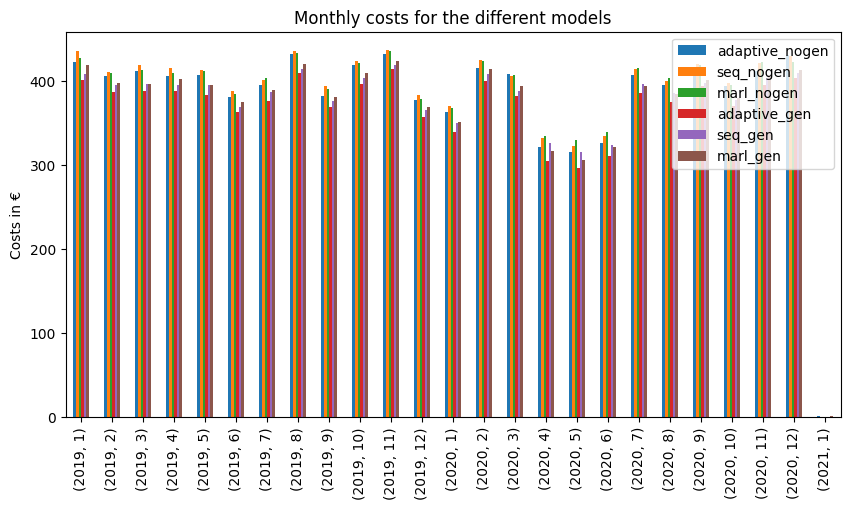

In [15]:
# Takes the df_costs_grouped and builds a bar plot

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

df_costs_grouped.plot(kind='bar', ax=ax)

ax.set_title('Monthly costs for the different models')
ax.set_ylabel('Costs in €')

plt.show()

In [14]:
# Create a dataframe highlighting the lowest cost per month

df_lowest_costs = pd.DataFrame({})
df_lowest_costs['adaptive_nogen'] = final_costs['priority_paper_v1']\
    [list(final_costs['priority_paper_v1'].columns)[:-1]].sum(axis=1)
df_lowest_costs['seq_nogen'] = final_costs['priority_seq_paper_v1']\
    [list(final_costs['priority_seq_paper_v1'].columns)[:-1]].sum(axis=1).values
df_lowest_costs['marl_nogen'] = final_costs['priority_baseline_paper_v1']\
    [list(final_costs['priority_baseline_paper_v1'].columns)[:-1]].sum(axis=1).values
#df_lowest_costs['adaptive_gen'] = final_costs['priority_paper_v0']\
#    [list(final_costs['priority_paper_v0'].columns)[:-1]].sum(axis=1)
#df_lowest_costs['seq_gen'] = final_costs['priority_seq_paper_v0']\
#    [list(final_costs['priority_seq_paper_v0'].columns)[:-1]].sum(axis=1).values
#df_lowest_costs['marl_gen'] = final_costs['priority_baseline_paper_v0']\
#    [list(final_costs['priority_baseline_paper_v0'].columns)[:-1]].sum(axis=1).values

df_lowest_costs['lowest'] = df_lowest_costs.idxmin(axis=1)
df_lowest_costs

,adaptive_nogen,seq_nogen,marl_nogen,lowest
2019-01-01 01:00:00,1.463665,2.32207,1.575547,adaptive_nogen
2019-01-01 02:00:00,1.227268,1.371864,0.620178,marl_nogen
2019-01-01 03:00:00,0.683326,0.545897,0.601822,seq_nogen
2019-01-01 04:00:00,0.347288,0.239376,0.838699,seq_nogen
2019-01-01 05:00:00,0.60317,0.207085,0.498144,seq_nogen
...,...,...,...,...
2020-12-31 20:00:00,0.369237,0.268036,0.526015,seq_nogen
2020-12-31 21:00:00,0.078371,0.085215,0.072959,marl_nogen
2020-12-31 22:00:00,0.283685,0.186174,0.375178,seq_nogen
2020-12-31 23:00:00,0.277827,0.294603,0.064197,marl_nogen


In [15]:
# Count the number of times each model is the lowest cost

df_lowest_costs.loc['2019-02':]['lowest'].value_counts()

lowest
adaptive_nogen    7700
seq_nogen         4811
marl_nogen        4290
Name: count, dtype: int64

In [16]:
# Group by month

df_lowest_grouped = pd.DataFrame({})
df_lowest_grouped['adaptive_nogen'] = df_lowest_costs['lowest'] == 'adaptive_nogen'
df_lowest_grouped['seq_nogen'] = df_lowest_costs['lowest'] == 'seq_nogen'
df_lowest_grouped['marl_nogen'] = df_lowest_costs['lowest'] == 'marl_nogen'

df_lowest_grouped = df_lowest_grouped['2019-02':]

df_lowest_grouped = df_lowest_grouped.groupby([df_lowest_grouped.index.hour]).sum()
df_lowest_grouped

,adaptive_nogen,seq_nogen,marl_nogen
0,76,335,290
1,96,374,230
2,110,432,158
3,246,340,114
4,378,239,83
5,441,207,52
6,504,159,37
7,350,311,39
8,402,263,35
9,491,152,57


NameError: name 'df_lowest_grouped' is not defined

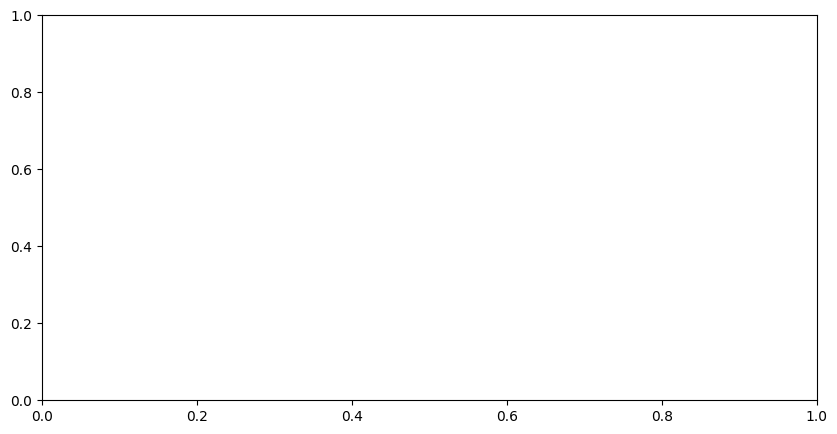

In [16]:
# Create a stacked bar plot for the lowest costs

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

df_lowest_grouped.plot(kind='bar', stacked=True, ax=ax, rot=0)

ax.set_title('Best approach per hour')
ax.set_ylabel('Frequency')
ax.set_xlabel('Time (h)')

plt.legend(['Adaptive', 'Turn-based', 'MARL'], title='Approach', loc='upper right')

plt.tight_layout()

#plt.savefig('best_approach_hourly.png', dpi=300)

plt.show()

In [18]:
df_lowest_grouped['highest'] = df_lowest_grouped.idxmax(axis=1)

In [19]:
df_lowest_grouped

,adaptive_nogen,seq_nogen,marl_nogen,highest
0,76,335,290,seq_nogen
1,96,374,230,seq_nogen
2,110,432,158,seq_nogen
3,246,340,114,seq_nogen
4,378,239,83,adaptive_nogen
5,441,207,52,adaptive_nogen
6,504,159,37,adaptive_nogen
7,350,311,39,adaptive_nogen
8,402,263,35,adaptive_nogen
9,491,152,57,adaptive_nogen


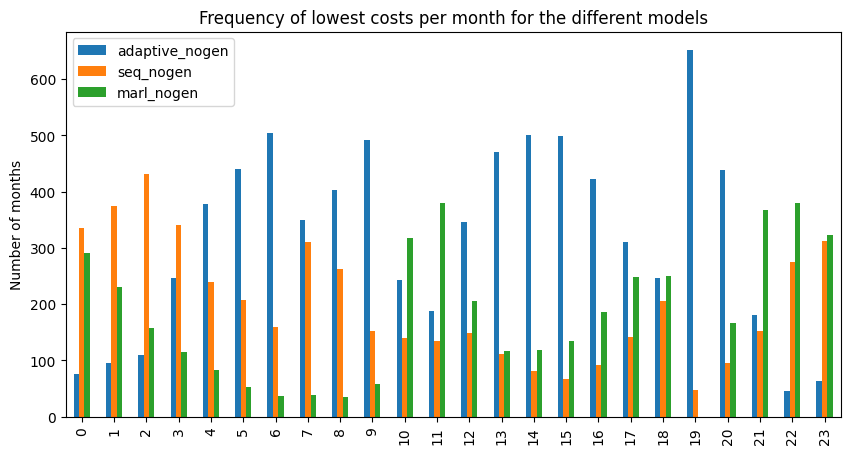

In [21]:
# Create a bar plot for the lowest costs

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

df_lowest_grouped.plot(kind='bar', ax=ax)

ax.set_title('Frequency of lowest costs per month for the different models')
ax.set_ylabel('Number of months')

plt.show()

In [17]:
# Get the sum of the costs for each hour of the day

df_costs_hourly = pd.DataFrame({})
df_costs_hourly['adaptive_nogen'] = final_costs['priority_paper_v1']\
    [list(final_costs['priority_paper_v1'].columns)[:-1]].sum(axis=1)['2019-02':'2019-12']
df_costs_hourly['seq_nogen'] = final_costs['priority_seq_paper_v1']\
    [list(final_costs['priority_seq_paper_v1'].columns)[:-1]].sum(axis=1)['2019-02':'2019-12':].values
df_costs_hourly['marl_nogen'] = final_costs['priority_baseline_paper_v1']\
    [list(final_costs['priority_baseline_paper_v1'].columns)[:-1]].sum(axis=1)['2019-02':'2019-12'].values

df_costs_hourly = df_costs_hourly.groupby([df_costs_hourly.index.hour]).sum()

# Add a new column with the lowest cost
df_costs_hourly['lowest_nogen'] = df_costs_hourly[['adaptive_nogen', 'seq_nogen', 'marl_nogen']].idxmin(axis=1)
df_costs_hourly

,adaptive_nogen,seq_nogen,marl_nogen,lowest_nogen
0,129.926438,124.202882,132.134146,seq_nogen
1,118.290661,117.262516,128.282315,seq_nogen
2,101.992856,100.559965,112.778648,seq_nogen
3,85.947553,85.452804,94.789928,seq_nogen
4,81.585768,82.586114,89.297086,adaptive_nogen
5,84.429182,84.156751,85.563361,seq_nogen
6,95.559415,96.608624,95.912641,adaptive_nogen
7,120.706793,110.225604,156.949604,seq_nogen
8,183.706471,177.112605,186.670491,seq_nogen
9,185.510317,188.625757,184.141498,marl_nogen


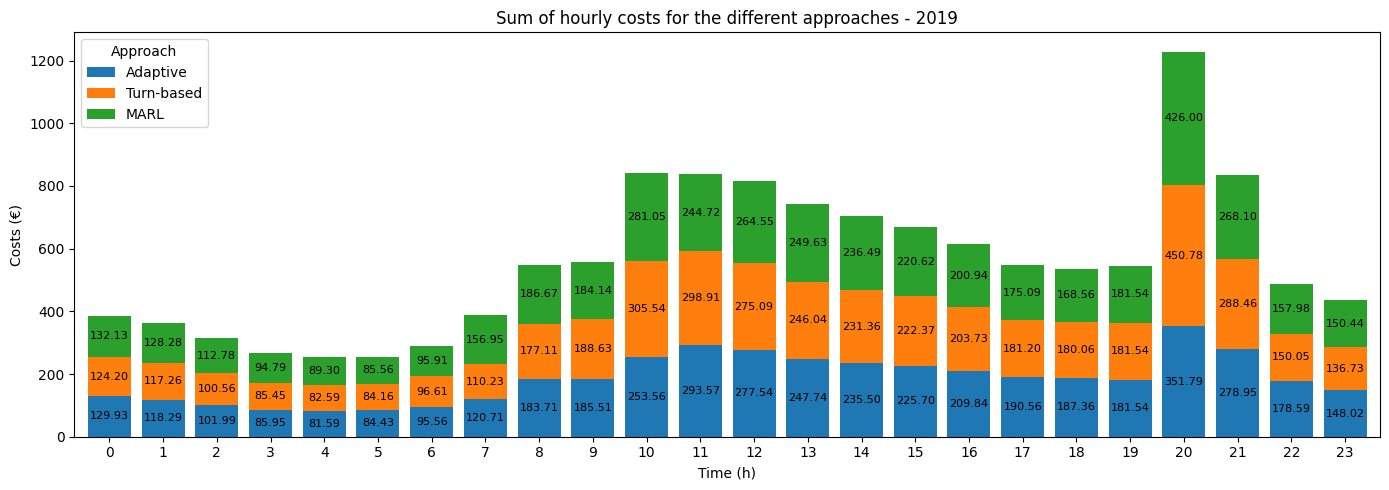

In [18]:
# Plot the hourly costs as a stacked bar

fig, ax = plt.subplots(1, 1, figsize=(14, 5))

df_costs_hourly.plot(kind='bar', stacked=True, ax=ax, rot=0, width=0.8)

for rect in ax.patches:
    # Find where everything is located
    height = rect.get_height()
    width = rect.get_width()
    x = rect.get_x()
    y = rect.get_y()

    # The height of the bar is the data value and can be used as the label
    label_text = f'{height:.2f}'  # f'{height:.2f}' to format decimal values

    # ax.text(x, y, text)
    label_x = x + width / 2
    label_y = y + height / 2

    # plot only when height is greater than specified value
    if height > 0:
        ax.text(label_x, label_y, label_text, ha='center', va='center', fontsize=8)

# Rotate the bar values
    
ax.set_ylabel('Costs (€)')
ax.set_xlabel('Time (h)')

ax.set_title('Sum of hourly costs for the different approaches - 2019')

plt.legend(['Adaptive', 'Turn-based', 'MARL'], title='Approach', loc='upper left')

plt.tight_layout()
#plt.savefig('hourly_costs_2019.png', dpi=300)

plt.show()

In [19]:
# Do the hourly costs for the 2020 data

df_costs_hourly_2020 = pd.DataFrame({})
df_costs_hourly_2020['adaptive_nogen'] = final_costs['priority_paper_v1']\
    [list(final_costs['priority_paper_v1'].columns)[:-1]].sum(axis=1)['2020']
df_costs_hourly_2020['seq_nogen'] = final_costs['priority_seq_paper_v1']\
    [list(final_costs['priority_seq_paper_v1'].columns)[:-1]].sum(axis=1)['2020'].values
df_costs_hourly_2020['marl_nogen'] = final_costs['priority_baseline_paper_v1']\
    [list(final_costs['priority_baseline_paper_v1'].columns)[:-1]].sum(axis=1)['2020'].values

df_costs_hourly_2020 = df_costs_hourly_2020.groupby([df_costs_hourly_2020.index.hour]).sum()

# Add a new column with the lowest cost
df_costs_hourly_2020['lowest_nogen'] = df_costs_hourly_2020[['adaptive_nogen', 'seq_nogen', 'marl_nogen']].idxmin(axis=1)
df_costs_hourly_2020

,adaptive_nogen,seq_nogen,marl_nogen,lowest_nogen
0,128.506254,120.468182,126.23885,seq_nogen
1,110.606067,107.882782,116.695412,seq_nogen
2,90.86288,87.90067,99.348052,seq_nogen
3,79.317886,76.39851,92.506669,seq_nogen
4,74.05411,72.329843,83.912666,seq_nogen
5,78.746303,78.579789,82.586748,seq_nogen
6,89.655155,89.991868,89.632199,marl_nogen
7,109.60854,98.309847,152.174574,seq_nogen
8,169.223921,164.766943,175.64143,seq_nogen
9,168.792094,171.760849,165.655652,marl_nogen


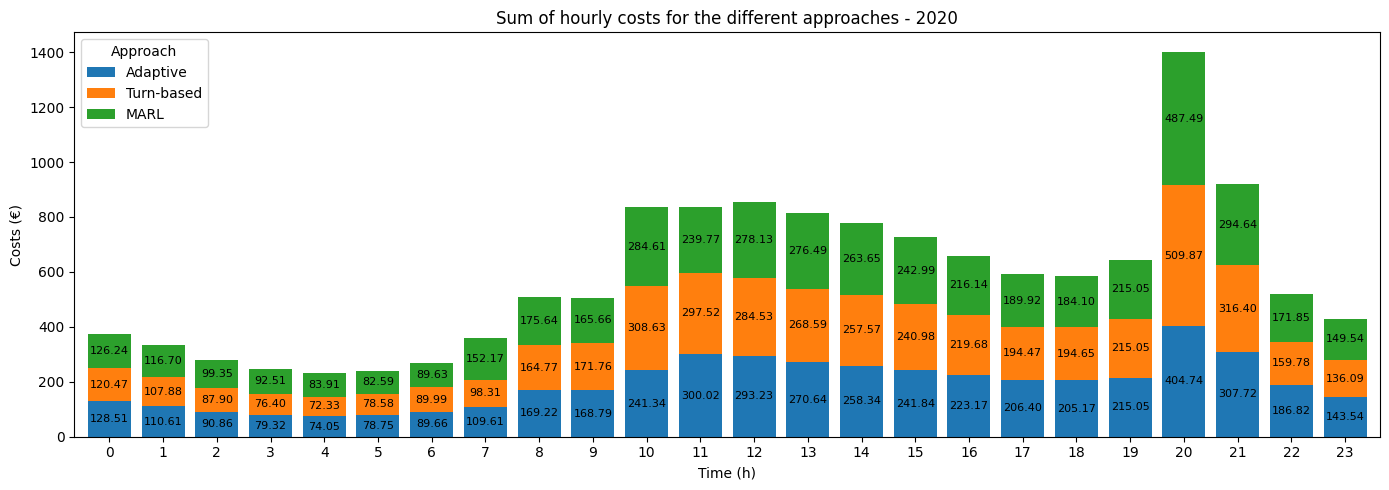

In [20]:
# Plot the hourly costs as a stacked bar

fig, ax = plt.subplots(1, 1, figsize=(14, 5))

df_costs_hourly_2020.plot(kind='bar', stacked=True, ax=ax, rot=0, width=0.8)

for rect in ax.patches:
    # Find where everything is located
    height = rect.get_height()
    width = rect.get_width()
    x = rect.get_x()
    y = rect.get_y()

    # The height of the bar is the data value and can be used as the label
    label_text = f'{height:.2f}'  # f'{height:.2f}' to format decimal values

    # ax.text(x, y, text)
    label_x = x + width / 2
    label_y = y + height / 2

    # plot only when height is greater than specified value
    if height > 0:
        ax.text(label_x, label_y, label_text, ha='center', va='center', fontsize=8)
        
# Rotate the bar values

ax.set_ylabel('Costs (€)')
ax.set_xlabel('Time (h)')

ax.set_title('Sum of hourly costs for the different approaches - 2020')

plt.legend(['Adaptive', 'Turn-based', 'MARL'], title='Approach', loc='upper left')

plt.tight_layout()

# plt.savefig('hourly_costs_2020.png', dpi=300)

plt.show()

In [183]:
# Get the order over time for the priority_paper_v1 model

df_order_history = pd.DataFrame({})
df_order_history['adaptive_nogen'] = test_data['priority_paper_v2']['order_history']
df_order_history.index = test_data['priority_paper_v2'].index

# Go through each hour and check the order
# Remove the ren_generators and aggregator from the lists
for idx in np.arange(len(df_order_history)):
    # While it's a string we'll replace the names to make it easier to read
    df_order_history.iloc[idx]['adaptive_nogen'] = df_order_history.iloc[idx]['adaptive_nogen'].replace('ren_generator_02', 'PV1')
    df_order_history.iloc[idx]['adaptive_nogen'] = df_order_history.iloc[idx]['adaptive_nogen'].replace('ren_generator_06', 'PV2')
    df_order_history.iloc[idx]['adaptive_nogen'] = df_order_history.iloc[idx]['adaptive_nogen'].replace('ren_generator_08', 'PV3')
    df_order_history.iloc[idx]['adaptive_nogen'] = df_order_history.iloc[idx]['adaptive_nogen'].replace('ren_generator_09', 'PV4')
    df_order_history.iloc[idx]['adaptive_nogen'] = df_order_history.iloc[idx]['adaptive_nogen'].replace('ren_generator_13', 'PV5')
    df_order_history.iloc[idx]['adaptive_nogen'] = df_order_history.iloc[idx]['adaptive_nogen'].replace('aggregator', 'Aggregator')
        
    df_order_history.iloc[idx]['adaptive_nogen'] = df_order_history.iloc[idx]['adaptive_nogen'].replace('ev_01', 'EV1')
    df_order_history.iloc[idx]['adaptive_nogen'] = df_order_history.iloc[idx]['adaptive_nogen'].replace('ev_02', 'EV2')
    df_order_history.iloc[idx]['adaptive_nogen'] = df_order_history.iloc[idx]['adaptive_nogen'].replace('ev_03', 'EV3')
    df_order_history.iloc[idx]['adaptive_nogen'] = df_order_history.iloc[idx]['adaptive_nogen'].replace('ev_04', 'EV4')
    df_order_history.iloc[idx]['adaptive_nogen'] = df_order_history.iloc[idx]['adaptive_nogen'].replace('ev_05', 'EV5')
    df_order_history.iloc[idx]['adaptive_nogen'] = df_order_history.iloc[idx]['adaptive_nogen'].replace('storage_01', 'BESS1')
    df_order_history.iloc[idx]['adaptive_nogen'] = df_order_history.iloc[idx]['adaptive_nogen'].replace('storage_02', 'BESS2')
    df_order_history.iloc[idx]['adaptive_nogen'] = df_order_history.iloc[idx]['adaptive_nogen'].replace('storage_03', 'BESS3')

    df_order_history.iloc[idx]['adaptive_nogen'] = df_order_history.iloc[idx]['adaptive_nogen'].split(',')[5:-1]
    
# Create a new column with the order as string
df_order_history['order_str'] = df_order_history['adaptive_nogen'].apply(lambda x: ', '.join(x))
    
# Add a column with the order encoded
unique_orders = sorted(set(df_order_history['order_str']))
encoded_orders = {ch: i for i, ch in enumerate(unique_orders)}
df_order_history['order'] = [encoded_orders[i] for i in df_order_history['order_str']]

In [184]:
df_order_history

,adaptive_nogen,order_str,order
2019-01-01 00:00:00,"[ 'EV2', 'EV4', 'EV1', 'EV5', 'EV3', 'BES...","'EV2', 'EV4', 'EV1', 'EV5', 'EV3', 'BESS...",39
2019-01-01 01:00:00,"[ 'EV5', 'EV4', 'EV3', 'EV2', 'EV1', 'BES...","'EV5', 'EV4', 'EV3', 'EV2', 'EV1', 'BESS...",44
2019-01-01 02:00:00,"[ 'EV5', 'EV4', 'EV3', 'EV1', 'EV2', 'BES...","'EV5', 'EV4', 'EV3', 'EV1', 'EV2', 'BESS...",43
2019-01-01 03:00:00,"[ 'EV5', 'EV4', 'EV3', 'EV1', 'EV2', 'BES...","'EV5', 'EV4', 'EV3', 'EV1', 'EV2', 'BESS...",43
2019-01-01 04:00:00,"[ 'EV5', 'EV4', 'EV1', 'EV3', 'EV2', 'BES...","'EV5', 'EV4', 'EV1', 'EV3', 'EV2', 'BESS...",42
...,...,...,...
2020-12-31 19:00:00,"[ 'EV1', 'EV2', 'BESS1', 'EV5', 'EV4', 'E...","'EV1', 'EV2', 'BESS1', 'EV5', 'EV4', 'EV...",26
2020-12-31 20:00:00,"[ 'EV1', 'EV2', 'BESS1', 'EV5', 'EV4', 'E...","'EV1', 'EV2', 'BESS1', 'EV5', 'EV4', 'EV...",26
2020-12-31 21:00:00,"[ 'EV1', 'EV2', 'BESS1', 'EV5', 'EV4', 'E...","'EV1', 'EV2', 'BESS1', 'EV5', 'EV4', 'EV...",26
2020-12-31 22:00:00,"[ 'EV1', 'EV2', 'BESS1', 'EV5', 'EV4', 'E...","'EV1', 'EV2', 'BESS1', 'EV5', 'EV4', 'EV...",26


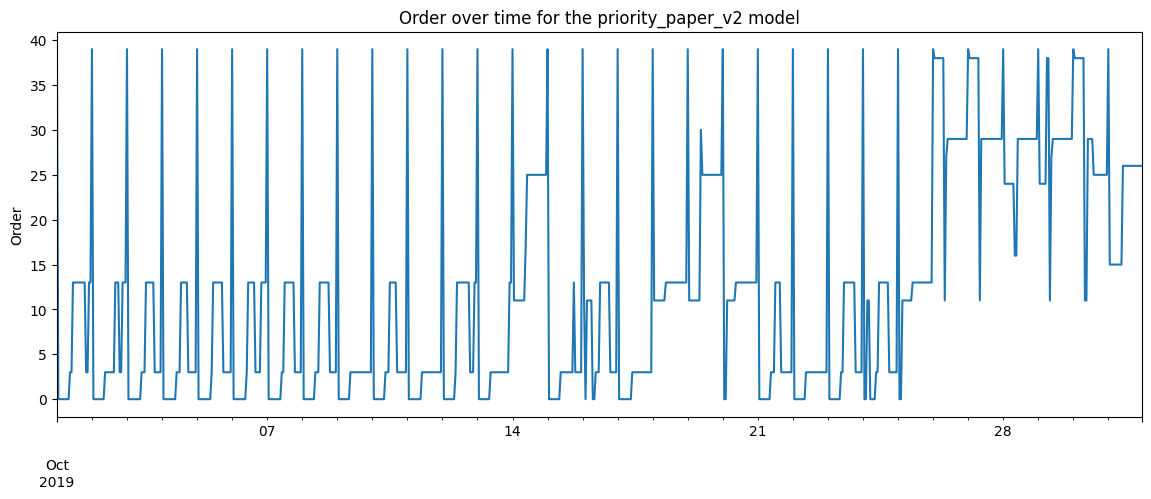

In [185]:
# Plot the order over time

fig, ax = plt.subplots(1, 1, figsize=(14, 5))

df_order_history['order']['2019-10'].plot(ax=ax)

ax.set_title('Order over time for the priority_paper_v2 model')
ax.set_ylabel('Order')

plt.show()

In [186]:
df_order_history['order']['2019-10-14']

2019-10-14 00:00:00    39
2019-10-14 01:00:00    11
2019-10-14 02:00:00    11
2019-10-14 03:00:00    11
2019-10-14 04:00:00    11
2019-10-14 05:00:00    11
2019-10-14 06:00:00    11
2019-10-14 07:00:00    11
2019-10-14 08:00:00    11
2019-10-14 09:00:00    17
2019-10-14 10:00:00    25
2019-10-14 11:00:00    25
2019-10-14 12:00:00    25
2019-10-14 13:00:00    25
2019-10-14 14:00:00    25
2019-10-14 15:00:00    25
2019-10-14 16:00:00    25
2019-10-14 17:00:00    25
2019-10-14 18:00:00    25
2019-10-14 19:00:00    25
2019-10-14 20:00:00    25
2019-10-14 21:00:00    25
2019-10-14 22:00:00    25
2019-10-14 23:00:00    25
Name: order, dtype: int64

In [14]:
test_data['priority_paper_v2']

,ren_generator_08,ren_generator_06,ren_generator_02,ren_generator_09,ren_generator_13,storage_01,storage_01_charge,storage_01_discharge,storage_02,storage_02_charge,...,ev_04,ev_04_charge,ev_04_discharge,ev_05,ev_05_charge,ev_05_discharge,imports,exports,energy_history,order_history
2019-01-01 00:00:00,0.0,0.001452,0.0,0.000012,0.0,0.715789,0.0,4.0,0.800000,0.0,...,0.776471,0.00,1.44,0.754416,0.00,2.88,0.00,0.608490,0.608490,"['ren_generator_08', 'ren_generator_06', 'ren_..."
2019-01-01 01:00:00,0.0,0.001365,0.0,0.000027,0.0,0.715789,0.0,0.0,0.737500,0.0,...,0.786000,0.72,0.00,0.708832,0.00,2.88,0.00,5.036803,5.036803,"['ren_generator_08', 'ren_generator_06', 'ren_..."
2019-01-01 02:00:00,0.0,0.001458,0.0,0.000025,0.0,0.715789,0.0,0.0,0.737500,0.0,...,0.762471,0.00,1.44,0.663248,0.00,2.88,0.00,0.858367,0.858367,"['ren_generator_08', 'ren_generator_06', 'ren_..."
2019-01-01 03:00:00,0.0,0.001522,0.0,0.000005,0.0,0.715789,0.0,0.0,0.737500,0.0,...,0.772000,0.72,0.00,0.617664,0.00,2.88,0.00,0.385942,0.385942,"['ren_generator_08', 'ren_generator_06', 'ren_..."
2019-01-01 04:00:00,0.0,0.001430,0.0,0.000008,0.0,0.715789,0.0,0.0,0.675000,0.0,...,0.748471,0.00,1.44,0.626895,0.72,0.00,0.00,5.443600,5.443600,"['ren_generator_08', 'ren_generator_06', 'ren_..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-31 19:00:00,0.0,0.000000,0.0,0.000000,0.0,0.199446,0.0,0.0,0.198437,0.0,...,0.009529,0.72,0.00,0.217486,0.72,0.00,0.72,0.000000,-0.720000,"['ren_generator_08', 'ren_generator_06', 'ren_..."
2020-12-31 20:00:00,0.0,0.000000,0.0,0.000000,0.0,0.199446,0.0,0.0,0.198437,0.0,...,0.019059,0.72,0.00,0.226717,0.72,0.00,0.72,0.000000,-0.720000,"['ren_generator_08', 'ren_generator_06', 'ren_..."
2020-12-31 21:00:00,0.0,0.000000,0.0,0.000000,0.0,0.199446,0.0,0.0,0.198437,0.0,...,0.028588,0.72,0.00,0.235947,0.72,0.00,0.72,0.000000,-0.720000,"['ren_generator_08', 'ren_generator_06', 'ren_..."
2020-12-31 22:00:00,0.0,0.000000,0.0,0.000000,0.0,0.199446,0.0,0.0,0.198437,0.0,...,0.038118,0.72,0.00,0.245178,0.72,0.00,0.72,0.000000,-0.720000,"['ren_generator_08', 'ren_generator_06', 'ren_..."


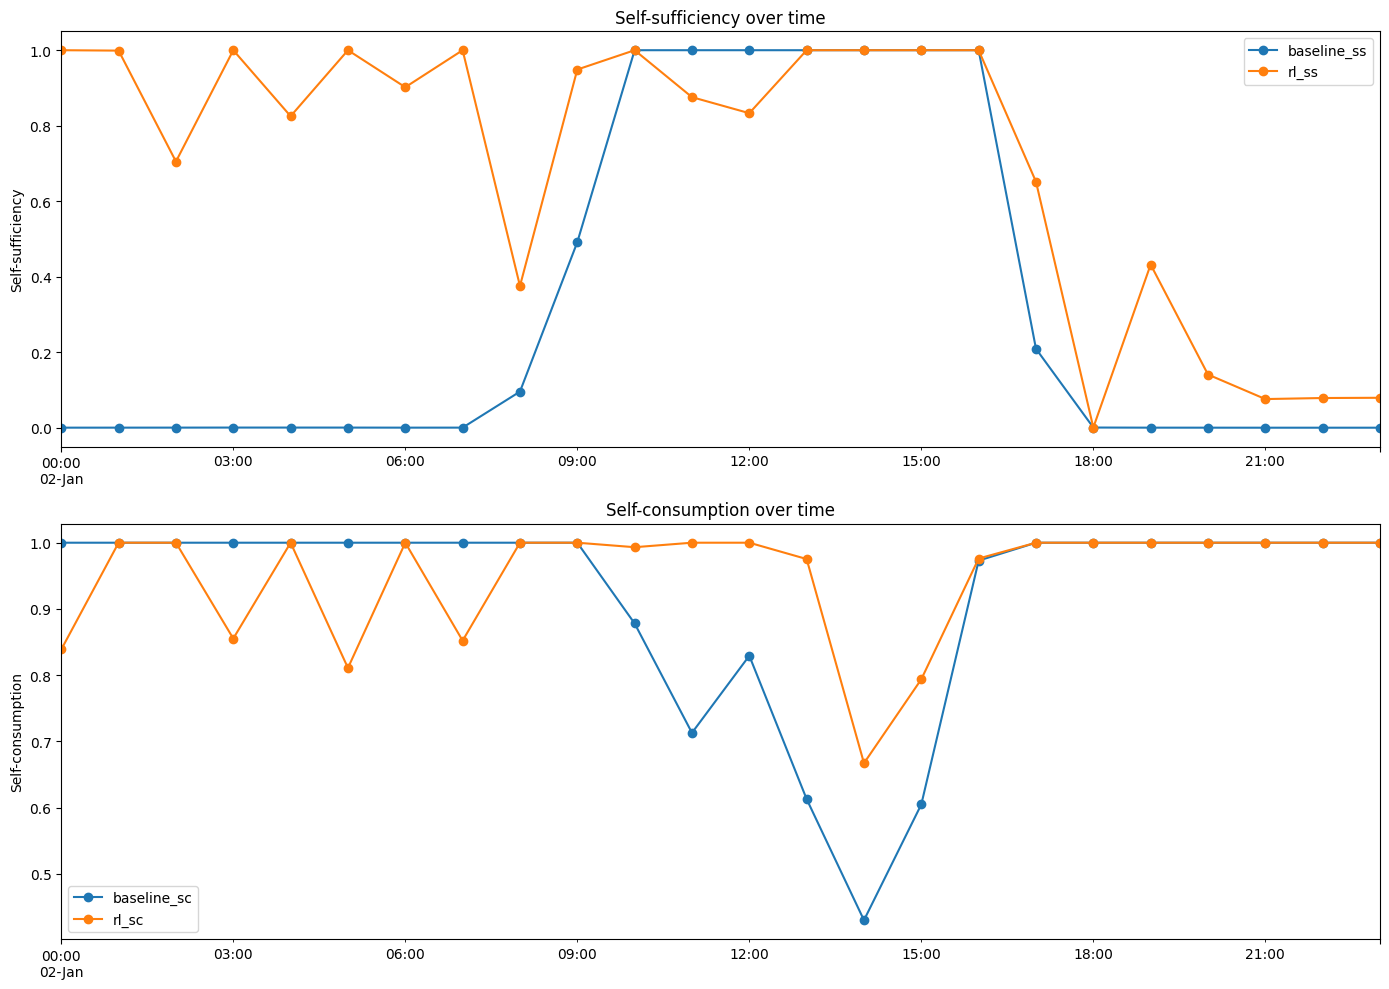

In [56]:
# Plot the SS and SC for the different models

fig, ax = plt.subplots(2, 1, figsize=(14, 10))

DAY = '2019-01-02'

df_ss_sc[['baseline_ss', 'rl_ss']].loc[DAY].plot(ax=ax[0], marker='o')

ax[0].set_title('Self-sufficiency over time')
ax[0].set_ylabel('Self-sufficiency')

df_ss_sc[['baseline_sc', 'rl_sc']].loc[DAY].plot(ax=ax[1], marker='o')

ax[1].set_title('Self-consumption over time')
ax[1].set_ylabel('Self-consumption')

plt.tight_layout()

plt.show()

In [37]:
consumptions[MODEL].keys()

Index(['load', 'storage_charge', 'ev_charge', 'exports'], dtype='object')

<Axes: >

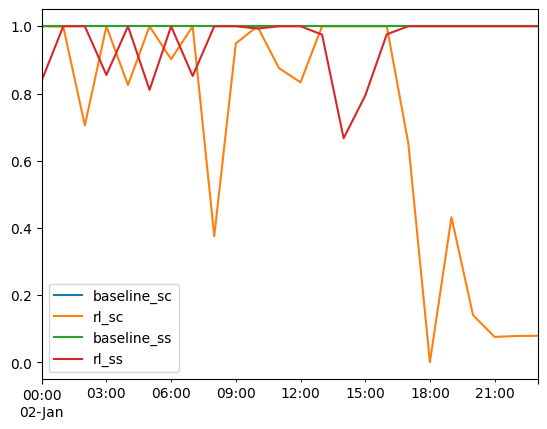

In [39]:
df_ss_sc.loc['2019-01-02'].plot()

In [31]:
test_data['priority_baseline_paper_v2'][['ren_generator_02', 'ren_generator_06',
                                         'ren_generator_08', 'ren_generator_09',
                                         'ren_generator_13']].sum(axis=1).loc['2019-01-02']

2019-01-02 00:00:00    0.0
2019-01-02 01:00:00    0.0
2019-01-02 02:00:00    0.0
2019-01-02 03:00:00    0.0
2019-01-02 04:00:00    0.0
2019-01-02 05:00:00    0.0
2019-01-02 06:00:00    0.0
2019-01-02 07:00:00    0.0
2019-01-02 08:00:00    0.0
2019-01-02 09:00:00    0.0
2019-01-02 10:00:00    0.0
2019-01-02 11:00:00    0.0
2019-01-02 12:00:00    0.0
2019-01-02 13:00:00    0.0
2019-01-02 14:00:00    0.0
2019-01-02 15:00:00    0.0
2019-01-02 16:00:00    0.0
2019-01-02 17:00:00    0.0
2019-01-02 18:00:00    0.0
2019-01-02 19:00:00    0.0
2019-01-02 20:00:00    0.0
2019-01-02 21:00:00    0.0
2019-01-02 22:00:00    0.0
2019-01-02 23:00:00    0.0
dtype: float64

In [22]:
sum(test_data['priority_baseline_paper_v2']['ev_01_discharge']>1)

0